<a href="https://colab.research.google.com/github/noobylub/Computational-Linguistic/blob/master/LELA30642_Week_8_DataVisualisation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LELA30642: Data Visualisation in Python


### Matplotlib
https://matplotlib.org/

The primary tool for data visualisation in Python is Matplotlib (so called because it was originally based on visualisation in Matlab).

It has very good documentation and can handle all sorts of plot types (https://matplotlib.org/stable/plot_types/index.html).

### Seaborn
(https://seaborn.pydata.org/)

This is another package built on Matplotlib the provides such shortcuts and additional functionality.

Rather that teaching you about the syntax of these libraries, I am going to use them in explaining how to visualise different kinds of variables you will generate in CCL work. You will learn about the packages along the way but you would do well to follow up by reading overview chapter:
https://wesmckinney.com/book/plotting-and-visualization
And the Matplotlib online documentation will tell you the rest.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

# Continuous Data

In [2]:
rng = np.random.default_rng()
mean = np.array([1.0,1.1])
cov = np.array([[1, 0.25], [0.25, 1]])
X=rng.multivariate_normal(mean, cov, 100)
df=pd.DataFrame(X,columns=["x","y"])

# Density plots

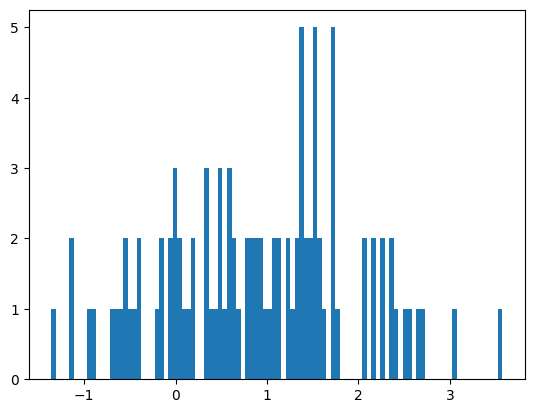

In [9]:
#plt.hist(X.T[0],bins=len(set(X.T[0])));
plt.hist(df["x"],bins=len(set(df["x"])));


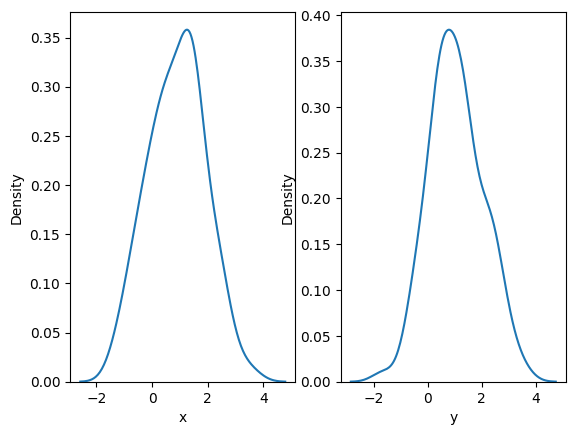

In [4]:
fig, axs = plt.subplots(ncols=2)
sns.kdeplot(df["x"],ax=axs[0]);
sns.kdeplot(df["y"],ax=axs[1]);

# Scatter plot

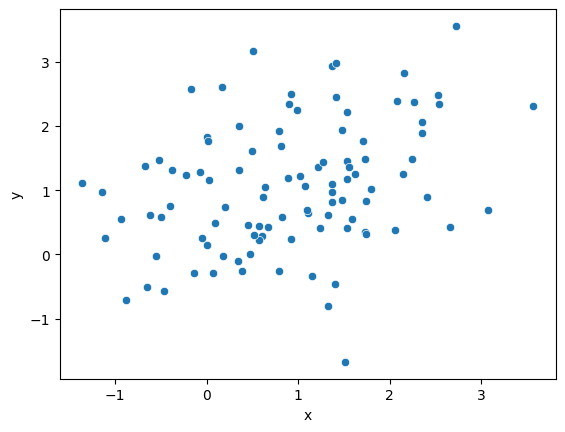

In [5]:
sns.scatterplot(data=df,x="x",y="y");

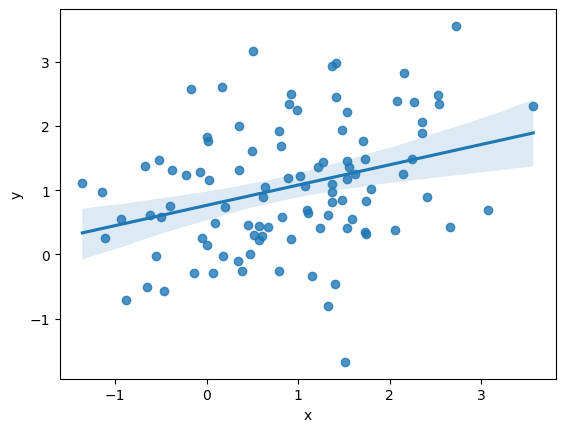

In [6]:
sns.regplot(data=df,x="x",y="y");

# Bar plot

In [15]:
df.mean(0)

,0
x,0.898160
y,1.048854


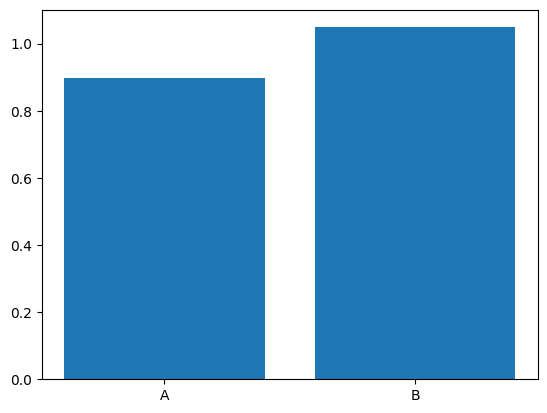

In [11]:
plt.bar(["A","B"], df.mean(0));
# The size estimate of the mean needs to be accounted for
# Make sure to understand what the error bar stands for

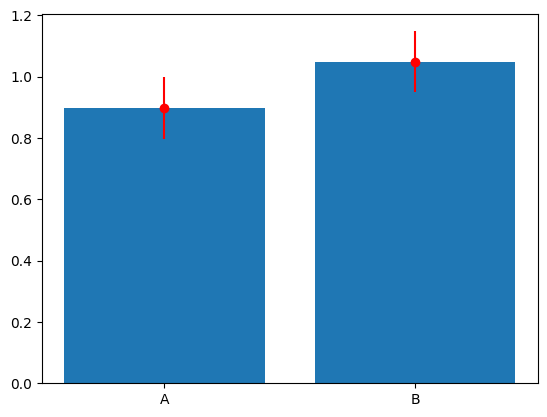

In [10]:
plt.bar(["A","B"], df.mean(0));
plt.errorbar(["A","B"], df.mean(0), yerr=df.sem(0), fmt="o", color="r");

# Non-normal continuous data

In [16]:
df_skew=pd.DataFrame(np.exp(X),columns=["x","y"])

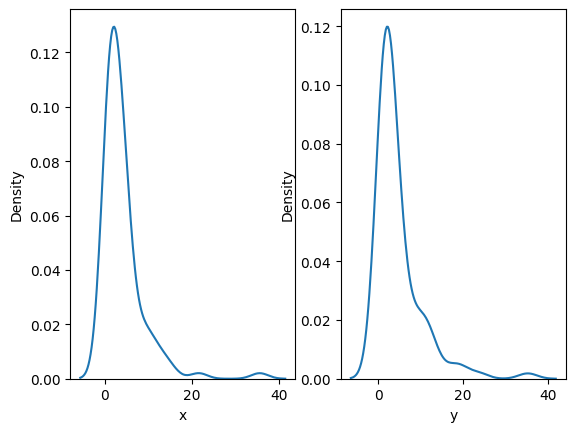

In [17]:
fig, axs = plt.subplots(ncols=2)
sns.kdeplot(df_skew["x"],ax=axs[0]);
sns.kdeplot(df_skew["y"],ax=axs[1]);

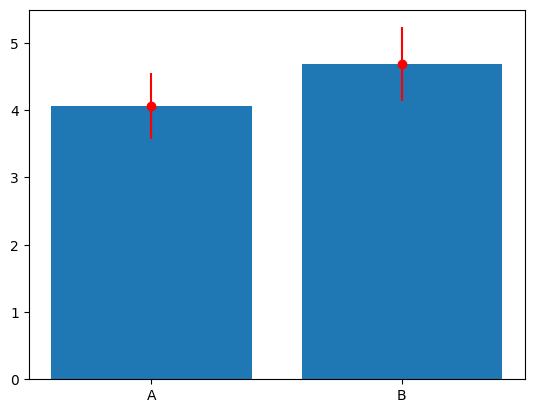

In [18]:
plt.bar(["A","B"], df_skew.mean(0));
plt.errorbar(["A","B"], df_skew.mean(0), yerr=df_skew.sem(0), fmt="o", color="r");

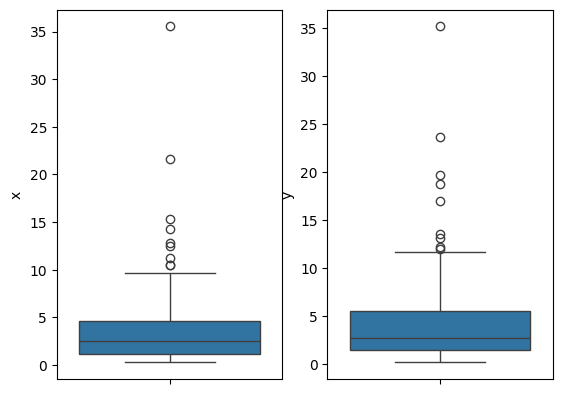

In [19]:
fig, axs = plt.subplots(ncols=2)
sns.boxplot(df_skew["x"],ax=axs[0]);
sns.boxplot(df_skew["y"],ax=axs[1]);

# Violin Plots

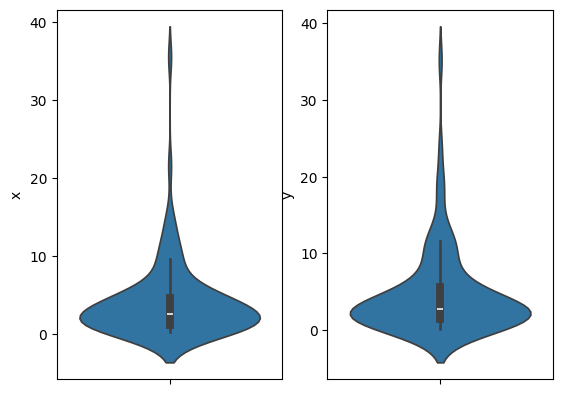

In [20]:
fig, axs = plt.subplots(ncols=2)
# Notice ax=axs[0] that signifies the subplot
sns.violinplot(df_skew["x"],ax=axs[0]);
sns.violinplot(df_skew["y"],ax=axs[1]);
# Plot of the distribution
# The left being hte X, the right side being the y

# Count Data

In [22]:
import re
from collections import Counter
# download from from the internt
!wget https://www.gutenberg.org/files/2554/2554-0.txt
# read in the file
f = open('2554-0.txt')
word_frequencies = Counter(f.read()[1:10000].split())
word_frequencies={k: v for k, v in sorted(word_frequencies.items(), key=lambda item: item[1])}
words = list(word_frequencies.keys())
counts = list(word_frequencies.values())
ranks=[]
for count in counts:
     ranks.append(counts.index(count))
ranks=np.max(ranks)-ranks+1

--2026-03-23 15:40:49--  https://www.gutenberg.org/files/2554/2554-0.txt
Resolving www.gutenberg.org (www.gutenberg.org)... 152.19.134.47, 2610:28:3090:3000:0:bad:cafe:47
Connecting to www.gutenberg.org (www.gutenberg.org)|152.19.134.47|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1159923 (1.1M) [text/plain]
Saving to: ‘2554-0.txt.1’

2554-0.txt.1        100%[===================>]   1.11M  --.-KB/s    in 0.1s    

2026-03-23 15:40:50 (7.86 MB/s) - ‘2554-0.txt.1’ saved [1159923/1159923]



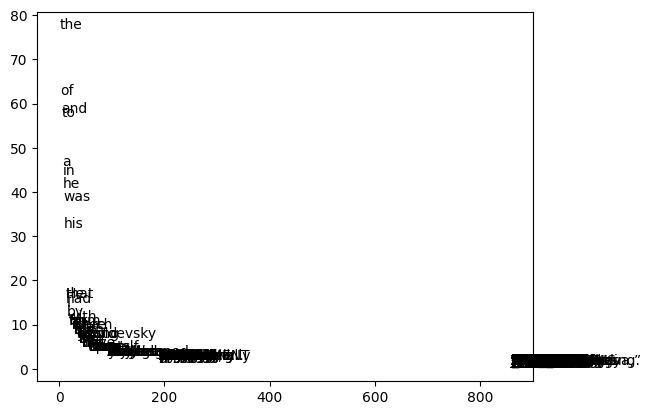

In [23]:
fig, ax = plt.subplots()
ax.scatter(ranks, counts, marker="")

for i, txt in enumerate(words):
    ax.annotate(txt, (ranks[i], counts[i]))

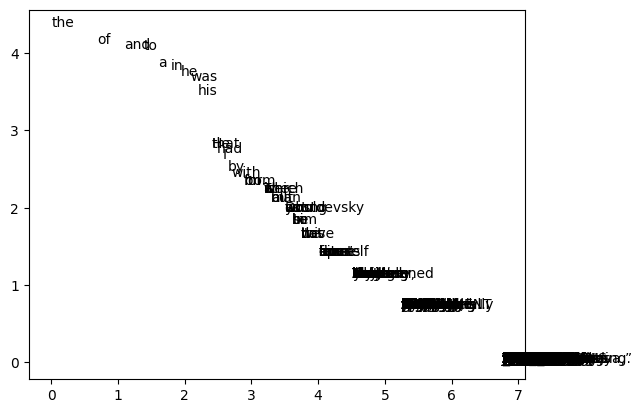

In [24]:
fig, ax = plt.subplots()
ax.scatter(np.log(ranks), np.log(counts), marker="")

for i, txt in enumerate(words):
    ax.annotate(txt, (np.log(ranks[i]), np.log(counts[i])))

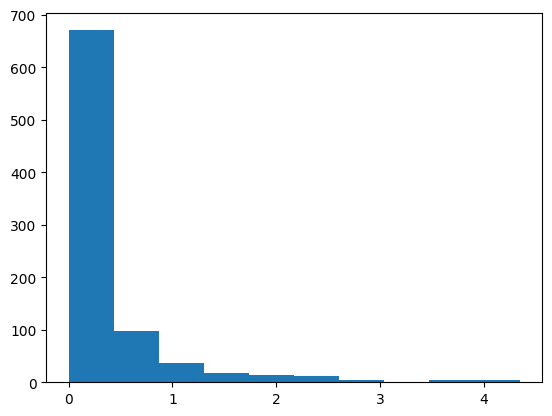

In [25]:
plt.hist(np.log(counts));

# Ordinal Data

In [ ]:
rng = np.random.default_rng()
plt.hist(np.round(rng.beta(a=0.5, b=0.5, size=1000),1)*10);

## Exercise 1

Download and import the example data as below. It reports reading time for a selections of English words in an experiment.
You will see three variables in the dataset:
CONDITIONAL_PROB - The n-gram probability of the word.
FIXATION_DURATION - The time people spent reading the word
GROUP - whether the reader's first language is English (0=yes,1=no)

In [26]:
!gdown 108BGZlRMFZahLxJ-kD_y2lq1XBpdGb-N

Downloading...
From: https://drive.google.com/uc?id=108BGZlRMFZahLxJ-kD_y2lq1XBpdGb-N
To: /content/example_distributions.csv
100% 285k/285k [00:00<00:00, 67.6MB/s]


In [27]:
dat=pd.read_csv("example_distributions.csv")

In [31]:
dat.head(5)

,Unnamed: 0,CONDITIONAL_PROB,FIXATION_DURATION,GROUP
0,1,0.537947,338,1
1,2,0.013006,196,1
2,3,0.066928,172,1
3,4,0.000149,188,1
4,5,0.001028,311,1


You should then do the following:
1. Determine the distributions of the variable by visualising them
2. Visualalise the relationship between reading time and probability, making any transformations required in order to make plot informative
3. Visualise the difference between the two groups, making any transformations required in order to make plot informative
4. Visualalise the relationship between reading time and probability for the two groups (L1 = English or not) separately, making any transformations required in order to make plots informative.
5. Put all the plots as subplots in a single figure.


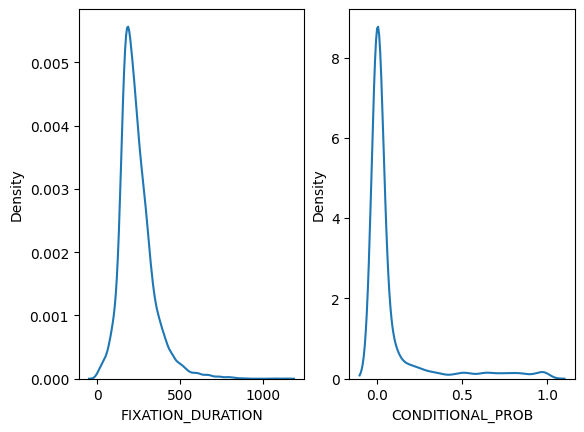

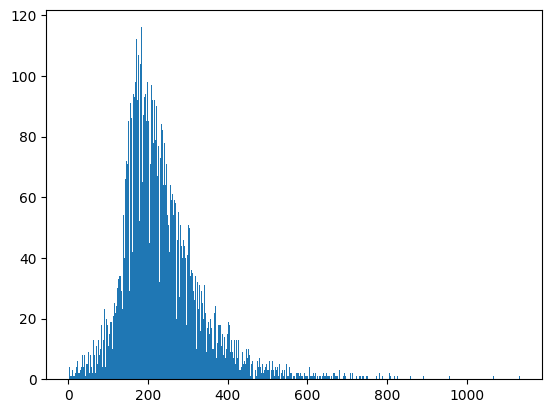

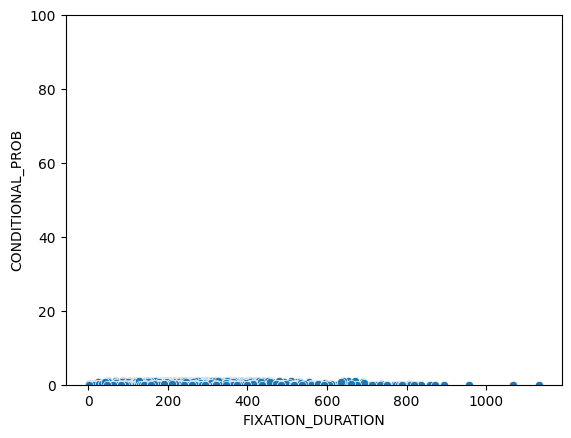

In [65]:
# Distribution plot
fig, axs = plt.subplots(ncols=2)
df=dat[["FIXATION_DURATION","CONDITIONAL_PROB"]]
sns.kdeplot(df["FIXATION_DURATION"],ax=axs[0]);
sns.kdeplot(df["CONDITIONAL_PROB"],ax=axs[1]);

# fig, axs = plt.subplots(ncols=2)
# sns.boxplot(df["FIXATION_DURATION"],ax=axs[0]);
# sns.boxplot(df["CONDITIONAL_PROB"],ax=axs[1]);

plt.subplots(ncols=1)
plt.hist(df["FIXATION_DURATION"],bins=len(set(df["FIXATION_DURATION"])));
plt.subplots(ncols=1)
factor = 2
hist_bin_width = 40
plt.ylim(0,100)
plt.hist(df["CONDITIONAL_PROB"],bins=len(set(df["CONDITIONAL_PROB"])));


# plotting



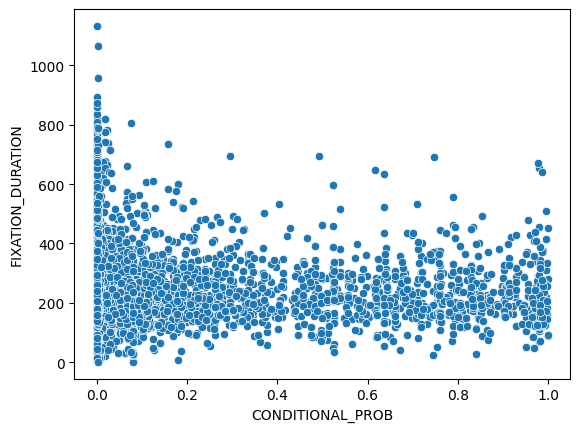

In [67]:
sns.scatterplot(data=df,x="CONDITIONAL_PROB",y="FIXATION_DURATION");

# Exercise 2
Download and import the example data as below. It two variables X and Y. Produce a plot with Y on vertical axis and X on the horizontal axis. Add a line to the plot that captures the observed relationship (it is not a straight line). To do this you will need to look at the package documentation to find the correct function and arguments.

In [49]:
!gdown 1wKtOYnK8dPo8oR-psuCudowZf_Dcqa0L
dat2=pd.read_csv("example_distributions2.csv")

Downloading...
From: https://drive.google.com/uc?id=1wKtOYnK8dPo8oR-psuCudowZf_Dcqa0L
To: /content/example_distributions2.csv
100% 33.8k/33.8k [00:00<00:00, 63.1MB/s]


In [50]:
dat2.head()

,X,Y
0,17.235923,177.775955
1,19.948066,169.130673
2,24.849351,279.553150
3,35.639972,565.508901
4,17.848467,181.850608


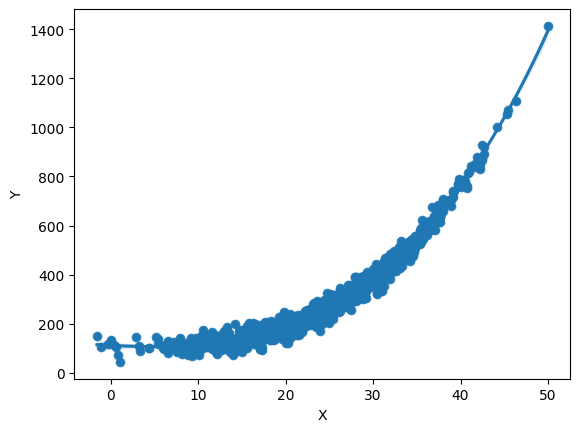

In [75]:
df = dat2[["X","Y"]]
sns.scatterplot(data=df,x="X",y="Y");
x=df['X']
y=df['Y']
sns.regplot(data=df,x="X",y="Y",order=4);
# a, b, c = np.polyfit(x, y, 2);

# plt.plot(x, a*x**2 + b*x + c,color='steelblue', linestyle='--', linewidth=2)
# sns.residplot(data=df,x="X",y="Y");